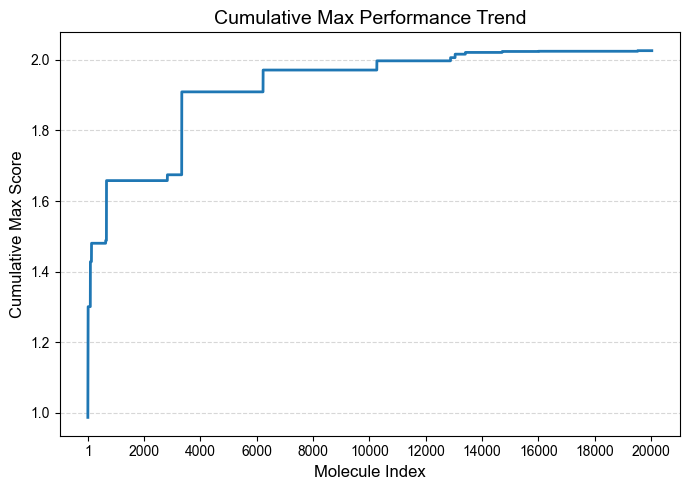

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np


rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False


df = pd.read_csv("RF+A+350+20000.csv")  


df['Index'] = range(1, len(df) + 1)


df['Cumulative Max Score'] = df['score'].cummax()


max_index = df['Index'].max()
xticks_pos = np.arange(0, max_index + 1, 2000)
xticks_pos[0] = 1 


plt.figure(figsize=(7, 5))
plt.plot(df['Index'], df['Cumulative Max Score'], linewidth=2)


plt.xticks(ticks=xticks_pos)


plt.xlabel("Molecule Index", fontsize=12)
plt.ylabel("Cumulative Max Score", fontsize=12)
plt.title("Cumulative Max Performance Trend", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


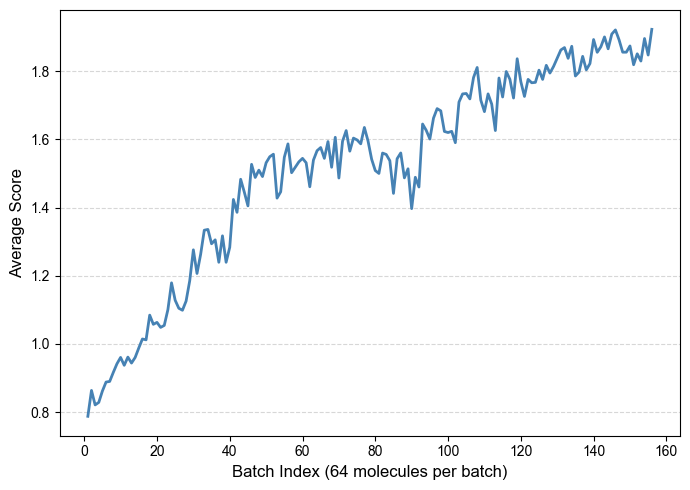

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np


rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False


df = pd.read_csv("RF+A+350+20000.csv")

df['Index'] = range(1, len(df) + 1)


batch_size = 128
num_batches = len(df) // batch_size


df_trimmed = df.iloc[:num_batches * batch_size].copy()


df_trimmed['Batch'] = df_trimmed.index // batch_size


batch_avg = df_trimmed.groupby('Batch')['score'].mean().reset_index()
batch_avg['Batch'] += 1  


plt.figure(figsize=(7, 5))
plt.plot(batch_avg['Batch'], batch_avg['score'], linewidth=2, color='steelblue')


plt.xlabel("Batch Index (64 molecules per batch)", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
#plt.title("Average Score per Batch", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


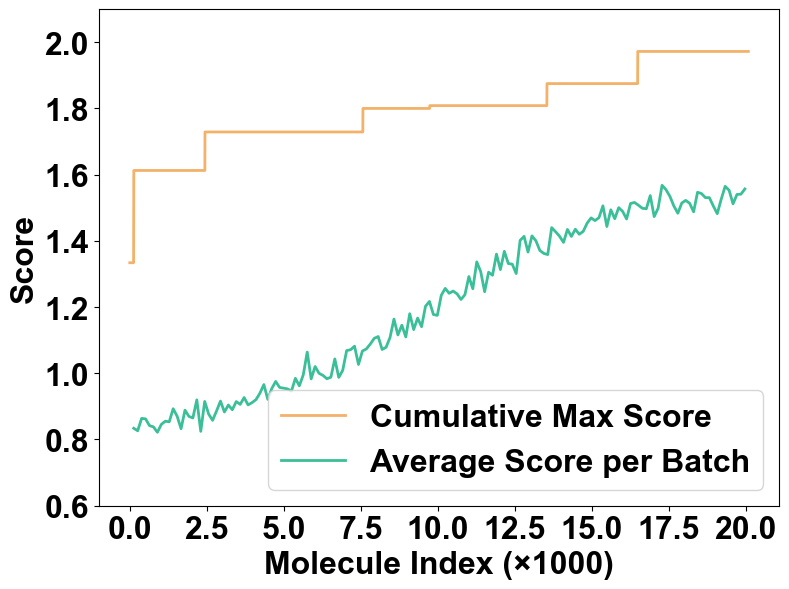

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np


rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False
rcParams['font.weight'] = 'bold'                

df = pd.read_csv("RF+A+350+20000.csv")
df['Index'] = range(1, len(df) + 1)
df['Cumulative Max Score'] = df['score'].cummax()


batch_size = 128
num_batches = len(df) // batch_size
df_trimmed = df.iloc[:num_batches * batch_size].copy()
df_trimmed['Batch'] = df_trimmed.index // batch_size
batch_avg = df_trimmed.groupby('Batch')['score'].mean().reset_index()
batch_avg['Batch Index'] = (batch_avg['Batch'] + 1) * batch_size


xticks_pos = np.arange(0, len(df)+1, 2500)
xticks_pos[0] = 1  
xticks_labels = [f"{x/1000:.1f}" for x in xticks_pos]


plt.figure(figsize=(8, 6))
plt.plot(df['Index'], df['Cumulative Max Score'], label='Cumulative Max Score', linewidth=2, color='#F3B169')
plt.plot(batch_avg['Batch Index'], batch_avg['score'], label='Average Score per Batch', linewidth=2, linestyle='-', color='#3ABF99')


plt.xlabel("Molecule Index (×1000)", fontsize=23)
plt.ylabel("Score", fontsize=23)
plt.xticks(ticks=xticks_pos, labels=xticks_labels, fontsize=23, fontweight='bold')
plt.yticks(fontsize=23, fontweight='bold')
plt.ylim(0.6,2.1)
plt.grid(False)
plt.legend(loc='lower right', fontsize=23)
plt.tight_layout()


plt.savefig("RF+A+350+20000.png", dpi=300, transparent=True)
plt.show()


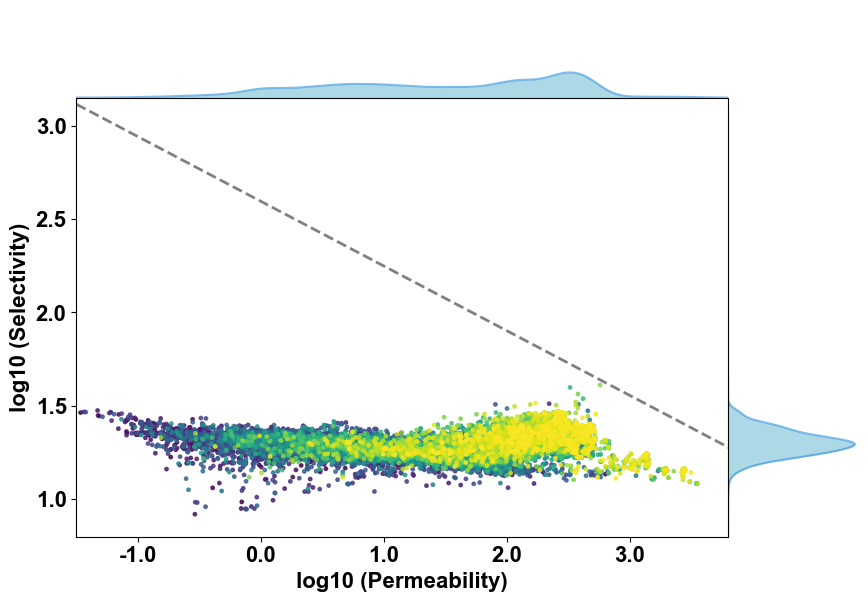

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams


rcParams['font.weight'] = 'bold' 
rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False
rcParams['axes.labelweight'] = 'bold'
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Arial Bold'

df = pd.read_csv('RF+A+350+20000.csv')
x = df['Penetrate']
y = df['Selective']
colors = np.arange(len(df))


a = 2.595
b = 0.3464
x_line = np.linspace(-1.5, a / b, 500)
y_line = a - b * x_line


g = sns.JointGrid(x=x, y=y, space=0, height=6, ratio=5)


g.ax_joint.scatter(x, y, c=colors, cmap='viridis', s=6, alpha=0.8)


g.ax_joint.plot(x_line, y_line, linestyle='--', linewidth=2, color='grey', label='y = 2.595 - 0.3464 * x')



sns.kdeplot(x, ax=g.ax_marg_x, fill=True, color='#ADD8E6', alpha=1, linewidth=0)
sns.kdeplot(x, ax=g.ax_marg_x, fill=False, color='#2C91E0', alpha=0.6,linewidth=1.5)

sns.kdeplot(y=y, ax=g.ax_marg_y, fill=True, color='#ADD8E6', alpha=1, linewidth=0)
sns.kdeplot(y=y, ax=g.ax_marg_y, fill=False, color='#2C91E0', alpha=0.6,linewidth=1.5)
g.ax_marg_x.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
g.ax_marg_y.tick_params(top=False, bottom=False, labelbottom=False, labelleft=False, left=False)


g.ax_marg_x.set_ylim(0, 2)  
g.ax_marg_y.set_xlim(0, 6)  
import matplotlib.ticker as ticker
g.ax_joint.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
g.ax_joint.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

g.ax_joint.set_xlabel('log10 (Permeability)', fontsize=16)
g.ax_joint.set_ylabel('log10 (Selectivity)', fontsize=16)
g.ax_joint.set_xlim(-1.5, 3.8)
g.ax_joint.set_ylim(0.8, 3.15)
g.ax_joint.tick_params(axis='both', labelsize=16)
g.ax_joint.grid(False)


g.fig.set_size_inches(9, 6)


plt.savefig("RF+A+350+20000.png", dpi=300, transparent=True)
plt.show()
